# Testing Out New Classes

In [1]:
from utils_3 import PairwiseData

In [2]:
from datasets import load_dataset

ds = load_dataset("lmarena-ai/arena-human-preference-140k", )
ds = dict(ds)

/home/jennifer/distortion/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
ds

{'train': Dataset({
     features: ['id', 'model_a', 'model_b', 'winner', 'evaluation_session_id', 'evaluation_order', 'conversation_a', 'conversation_b', 'full_conversation', 'conv_metadata', 'category_tag', 'language', 'is_code', 'timestamp'],
     num_rows: 135634
 })}

In [4]:
pw = PairwiseData(ds, M=20, N=20)

In [5]:
pw.winners

array([ 1, 12,  4, ...,  7,  5, 11], shape=(17073,))

In [6]:
import numpy as np
subgroups, count = np.unique(pw.subgroups, return_counts=True)

In [7]:
subgroups

array([   0,   64,   68,   76,   92,  100,  192,  224,  240,  248,  252,
        364,  366,  380,  508,  509, 1276, 1404, 1532, 1533], dtype=uint32)

In [8]:
count

array([2108,  840,  821,  645,  330,  377,  431,  507,  647,  785,  736,
        323,  390,  546, 1205, 1077,  673, 1018, 2032, 1582])

In [9]:
len(subgroups)

20

In [10]:
pw.candidates_to_idx

{np.str_('claude-opus-4-20250514'): 0,
 np.str_('gemini-2.5-pro'): 1,
 np.str_('gemini-2.5-flash'): 2,
 np.str_('qwen3-235b-a22b-no-thinking'): 3,
 np.str_('mistral-medium-2505'): 4,
 np.str_('o3-2025-04-16'): 5,
 np.str_('claude-sonnet-4-20250514'): 6,
 np.str_('chatgpt-4o-latest-20250326'): 7,
 np.str_('claude-3-7-sonnet-20250219-thinking-32k'): 8,
 np.str_('gemma-3-27b-it'): 9,
 np.str_('claude-3-7-sonnet-20250219'): 10,
 np.str_('claude-3-5-sonnet-20241022'): 11,
 np.str_('o3-mini'): 12,
 np.str_('command-a-03-2025'): 13,
 np.str_('deepseek-r1-0528'): 14,
 np.str_('claude-3-5-haiku-20241022'): 15,
 np.str_('gpt-4.1-2025-04-14'): 16,
 np.str_('o4-mini-2025-04-16'): 17,
 np.str_('claude-opus-4-20250514-thinking-16k'): 18,
 np.str_('amazon.nova-pro-v1:0'): 19}

In [11]:
set(pw.subgroups)

{np.uint32(0),
 np.uint32(64),
 np.uint32(68),
 np.uint32(76),
 np.uint32(92),
 np.uint32(100),
 np.uint32(192),
 np.uint32(224),
 np.uint32(240),
 np.uint32(248),
 np.uint32(252),
 np.uint32(364),
 np.uint32(366),
 np.uint32(380),
 np.uint32(508),
 np.uint32(509),
 np.uint32(1276),
 np.uint32(1404),
 np.uint32(1532),
 np.uint32(1533)}

In [12]:
pw.data_by_subgroups([204])

{'winners': array([], dtype=int64),
 'losers': array([], dtype=int64),
 'subgroups': array([], dtype=uint32)}

In [13]:
import numpy as np

s, c = np.unique(pw.subgroups, return_counts=True)

In [14]:
np.sort(-c)

array([-2108, -2032, -1582, -1205, -1077, -1018,  -840,  -821,  -785,
        -736,  -673,  -647,  -645,  -546,  -507,  -431,  -390,  -377,
        -330,  -323])

In [15]:
from utils_3 import Population

population = Population(pw)

100%|██████████| 20/20 [00:00<00:00, 44.11it/s]


In [16]:
population.population_utilities

array([[0.31269992, 0.4573313 , 0.36681111, 0.31564378, 0.42508284,
        0.46199427, 0.32709657, 0.50704703, 0.35430598, 0.36653391,
        0.22639518, 0.26819843, 0.34659785, 0.34228249, 0.44821466,
        0.26387385, 0.42103525, 0.43984071, 0.26663267, 0.2829926 ],
       [0.44083992, 0.59466958, 0.48168534, 0.46476387, 0.4410316 ,
        0.60297879, 0.26751756, 0.51324286, 0.22711187, 0.5298326 ,
        0.37006173, 0.38681126, 0.25811608, 0.46224697, 0.5787432 ,
        0.18765818, 0.47644714, 0.41101253, 0.4184552 , 0.2829926 ],
       [0.25366034, 0.6687349 , 0.45624436, 0.48058831, 0.43380037,
        0.50898005, 0.2449173 , 0.46444491, 0.15863656, 0.40476255,
        0.14702435, 0.19986904, 0.2586914 , 0.34825086, 0.60903863,
        0.20576544, 0.42152067, 0.51392314, 0.29572103, 0.2829926 ],
       [0.36775181, 0.53804524, 0.3928652 , 0.41558873, 0.4365487 ,
        0.4928889 , 0.35733975, 0.55412419, 0.25027915, 0.38515488,
        0.07389325, 0.23357159, 0.26128176, 0

In [17]:
population.population_utilities.shape

(20, 20)

20


/tmp/ipykernel_2630688/810173394.py:19: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


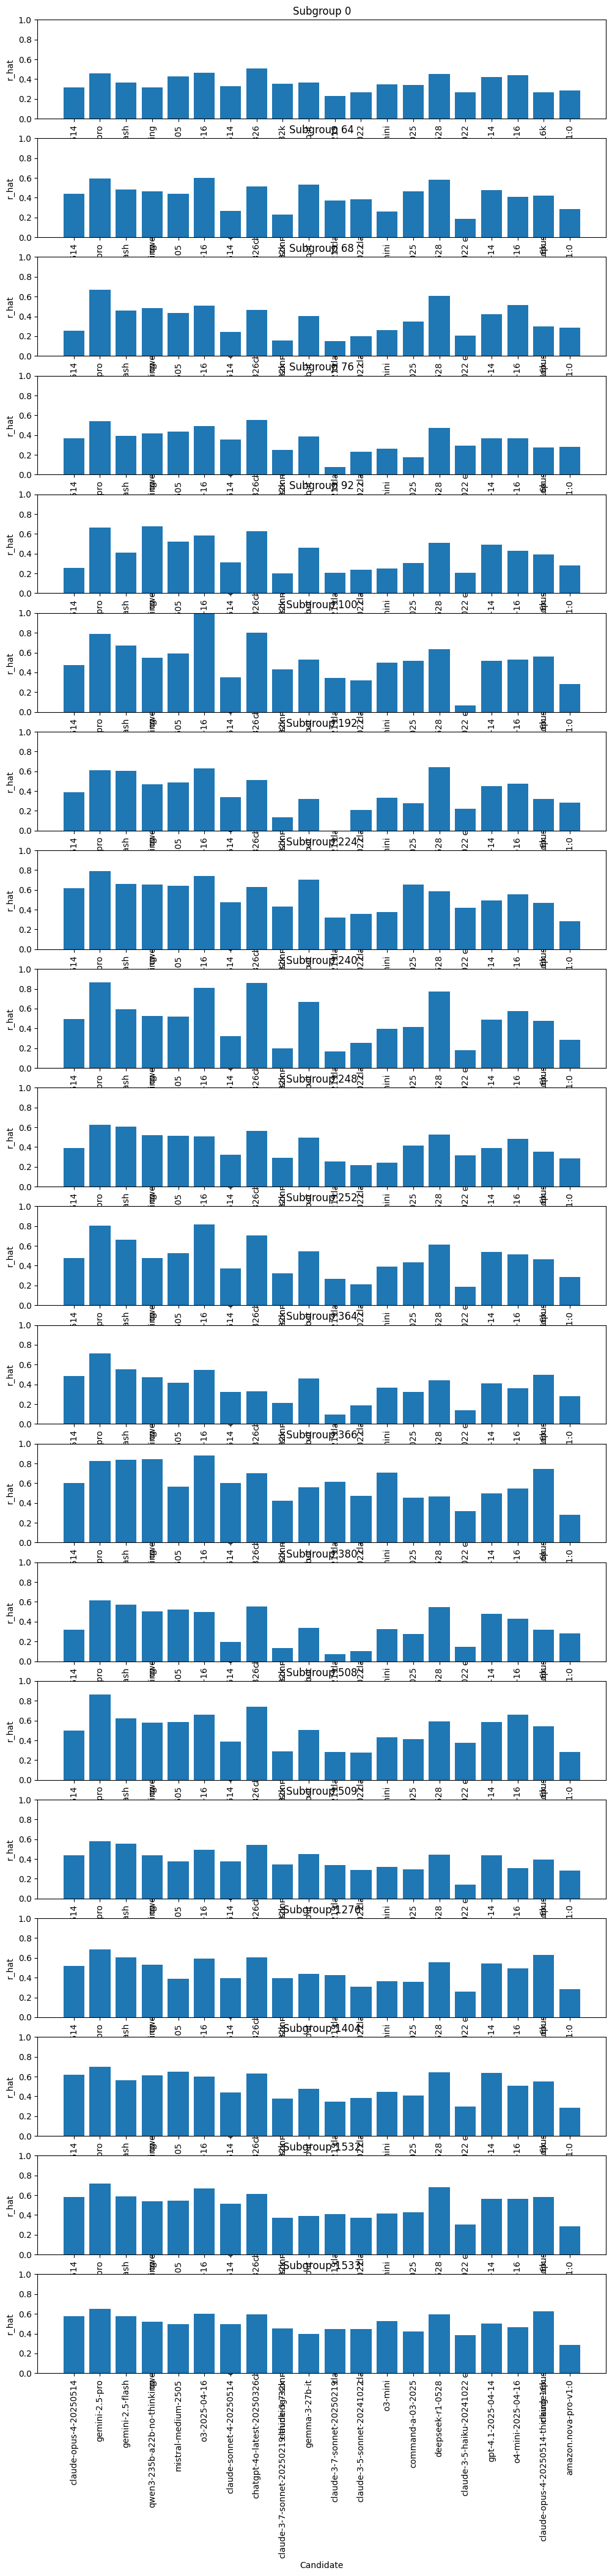

In [18]:
import matplotlib.pyplot as plt

num_subgroups, num_candidates = population.population_utilities.shape
print(num_subgroups)
fig, axes = plt.subplots(num_subgroups, 1, figsize=(12, max(3, 2.5 * num_subgroups)), squeeze=False)
candidate_labels = [pw.idx_to_candidates[i] for i in range(num_candidates)]

for row_idx, ax in enumerate(axes[:, 0]):
    subgroup = population.idx_to_subgroup[row_idx]
    r_hat = population.population_utilities[row_idx]
    ax.bar(np.arange(num_candidates), r_hat)
    ax.set_title(f'Subgroup {subgroup}')
    ax.set_ylabel('r_hat')
    ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


In [19]:
from utils_3 import misspecification_error

In [20]:
population.subgroup_to_idx

{np.uint32(0): 0,
 np.uint32(64): 1,
 np.uint32(68): 2,
 np.uint32(76): 3,
 np.uint32(92): 4,
 np.uint32(100): 5,
 np.uint32(192): 6,
 np.uint32(224): 7,
 np.uint32(240): 8,
 np.uint32(248): 9,
 np.uint32(252): 10,
 np.uint32(364): 11,
 np.uint32(366): 12,
 np.uint32(380): 13,
 np.uint32(508): 14,
 np.uint32(509): 15,
 np.uint32(1276): 16,
 np.uint32(1404): 17,
 np.uint32(1532): 18,
 np.uint32(1533): 19}

In [21]:
data = pw.data_by_subgroups([1533])
winners = data['winners']
losers = data['losers']

In [22]:
r_hat

array([0.57677468, 0.64791019, 0.57450252, 0.51796042, 0.49509629,
       0.59854427, 0.49636409, 0.59235972, 0.45044133, 0.39476512,
       0.44586497, 0.4452973 , 0.52719401, 0.42475823, 0.59632173,
       0.38271843, 0.50511497, 0.46519471, 0.62645001, 0.2829926 ])

In [23]:
r_hat = population.population_utilities[population.subgroup_to_idx[1533]]

misspecification_error(winners, losers, r_hat)

np.float64(133.8305520476556)

In [24]:
avg_utils = population.avg_utilities

In [25]:
misspecification_error(winners, losers, avg_utils)

np.float64(134.9297827645356)

In [26]:
for subgroup, i in population.subgroup_to_idx.items():
    data = pw.data_by_subgroups([subgroup])
    winners = data['winners']
    losers = data['losers'] 

    r_hat = population.population_utilities[i]
    msspec_r_hat = misspecification_error(winners, losers, r_hat)
    msspec_avg = misspecification_error(winners, losers, population.single_latent_r_hat)

    # if msspec_r_hat > msspec_avg:

    print('\nsubgroup:', subgroup)
    print('subgroup size:', len(winners))
    # print('r_hat:', r_hat)
    print('msspec r_hat:', msspec_r_hat)
    print('msspec avg_utils:', msspec_avg)

    print('normalized msspec r_hat:', msspec_r_hat / len(winners))
    print('normalized msspec avg_utils:', msspec_avg / len(winners))


subgroup: 0
subgroup size: 2108
msspec r_hat: 124.44039565684207
msspec avg_utils: 134.2991976448807
normalized msspec r_hat: 0.05903244575751521
normalized msspec avg_utils: 0.0637092967954842

subgroup: 64
subgroup size: 840
msspec r_hat: 142.96679420809792
msspec avg_utils: 126.57234982588213
normalized msspec r_hat: 0.17019856453344992
normalized msspec avg_utils: 0.15068136884033587

subgroup: 68
subgroup size: 821
msspec r_hat: 149.1289677837509
msspec avg_utils: 120.69787687434851
normalized msspec r_hat: 0.18164307890834458
normalized msspec avg_utils: 0.14701324832441962

subgroup: 76
subgroup size: 645
msspec r_hat: 142.8965046750286
msspec avg_utils: 128.04277912144184
normalized msspec r_hat: 0.22154496848841645
normalized msspec avg_utils: 0.19851593662239045

subgroup: 92
subgroup size: 330
msspec r_hat: 94.30713426925018
msspec avg_utils: 83.30056466524127
normalized msspec r_hat: 0.2857791947553036
normalized msspec avg_utils: 0.25242595353103414

subgroup: 100
subgrou

In [27]:
from utils_3 import borda_from_population_utilities

In [28]:
borda_scores, ranking = borda_from_population_utilities(population.population_utilities, population.voter_distr, beta=0.5)

In [29]:
true_ranking = np.argsort(-population.avg_utilities)

In [30]:
from utils_3 import leaderboard_dist

In [31]:
leaderboard_dist(ranking, true_ranking, population.avg_utilities)

(np.float64(1.0), np.int64(0))

In [32]:
ranking

array([ 1,  5,  7, 14,  2,  3,  4, 16, 17,  0, 18,  9, 13,  6, 12,  8, 11,
       10, 19, 15])

In [33]:
true_ranking

array([ 1,  5,  7, 14,  2,  3,  4, 16, 17,  0, 18,  9, 13,  6, 12,  8, 11,
       10, 19, 15])

In [ ]:
train_data = ds['train']

{'train': Dataset({
     features: ['id', 'model_a', 'model_b', 'winner', 'evaluation_session_id', 'evaluation_order', 'conversation_a', 'conversation_b', 'full_conversation', 'conv_metadata', 'category_tag', 'language', 'is_code', 'timestamp'],
     num_rows: 135634
 })}